In [1]:
from sklearn.model_selection import train_test_split
import xgboost
import shap
import numpy as np
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats.stats import pearsonr
shap.initjs()

In [2]:
df = pd.read_csv('mPC_CC.csv')

In [3]:
X = df.iloc[:,2:]
X

,apol,ast_fraglike,ast_fraglike_ext,ast_violation,ast_violation_ext,a_acc,a_acid,a_aro,a_base,a_count,...,CC_PhaseA_FA_per,CC_PhaseA_TFA_per,CC_PhaseB_O_pKa,CC_PhaseB_O_per,CC_PhaseB_W_per,CC_PhaseB_FA_per,CC_PhaseB_TFA_per,CC_RT-initial,CC_RT-final,CC_time
0,112.378930,0,0,3,5,10,0,17,0,94,...,0.1,0.00,-4.3,99.90,0,0.1,0.00,0.5,95,10.0
1,124.753270,0,0,3,5,10,0,17,0,106,...,0.1,0.00,-4.3,99.90,0,0.1,0.00,0.5,95,10.0
2,134.730850,0,0,3,5,12,0,23,0,114,...,0.1,0.00,-4.3,99.90,0,0.1,0.00,0.5,95,10.0
3,118.295680,0,0,3,5,8,0,17,0,100,...,0.1,0.00,-4.3,99.90,0,0.1,0.00,0.5,95,10.0
4,113.712520,0,0,3,5,10,0,17,0,96,...,0.1,0.00,-4.3,99.90,0,0.1,0.00,0.5,95,10.0
5,126.682850,0,0,3,5,10,0,17,0,108,...,0.1,0.00,-4.3,99.90,0,0.1,0.00,0.5,95,10.0
6,148.783580,0,0,4,6,11,0,22,0,128,...,0.1,0.00,-4.3,99.90,0,0.1,0.00,0.5,95,10.0
7,149.471160,0,0,4,6,9,0,22,0,128,...,0.1,0.00,-4.3,99.90,0,0.1,0.00,0.5,95,10.0
8,147.981580,0,0,4,6,11,0,22,0,127,...,0.1,0.00,-4.3,99.90,0,0.1,0.00,0.5,95,10.0
9,151.075160,0,0,4,6,11,0,22,0,130,...,0.1,0.00,-4.3,99.90,0,0.1,0.00,0.5,95,10.0


In [4]:
y= df.iloc[:,1]
y

0      7.110
1      7.930
2      8.480
3      9.000
4      7.710
5      5.960
6      7.740
7      8.260
8      8.110
9      8.090
10     6.390
11     8.340
12     8.970
13     7.020
14     7.620
15     8.860
16     8.020
17     8.520
18     8.170
19     6.630
20     8.460
21     8.060
22     7.100
23     5.570
24     6.480
25     8.110
26     6.880
27     6.970
28     5.880
29     9.180
       ...  
390    2.488
391    2.523
392    2.240
393    2.421
394    2.441
395    2.503
396    2.386
397    2.423
398    2.738
399    2.556
400    3.851
401    3.698
402    5.229
403    3.762
404    4.195
405    4.073
406    4.041
407    4.262
408    4.170
409    4.200
410    4.230
411    4.190
412    4.170
413    4.580
414    4.520
415    1.136
416    1.211
417    1.299
418    1.080
419    1.094
Name: rt_min, Length: 420, dtype: float64

In [5]:
from sklearn.model_selection import train_test_split
random_seeds = [2**n for n in range(10)]
for seed in random_seeds:
    # 使用相同的 seed 值来分割训练和验证集
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=seed)

    # 再次使用相同的 seed 值来进一步分割验证集，创建测试集
    X_test, X_temp, y_test, y_temp = train_test_split(X_val, y_val, test_size=0.1, random_state=seed)

In [6]:
model_xgb = xgboost.XGBRegressor(gpu_id = 0,tree_method = 'gpu_hist',objective ='reg:squarederror',
						max_depth=5,#nthread=cpu_cores,					
						learning_rate=0.05, n_estimators=2000, gamma=0,min_child_weight=5,max_delta_step=1,  
						subsample=0.53,colsample_bytree=0.66, colsample_bylevel=1,reg_alpha=0,
						reg_lambda=1,scale_pos_weight=1, base_score=0.5,seed=123)

In [7]:
from sklearn.model_selection import train_test_split
random_seeds = [2**n for n in range(10)]
for seed in random_seeds:
    # 使用相同的 seed 值来分割训练和验证集
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=seed)

    # 再次使用相同的 seed 值来进一步分割验证集，创建测试集
    X_test, X_temp, y_test, y_temp = train_test_split(X_val, y_val, test_size=0.1, random_state=seed)

In [8]:
model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
       colsample_bynode=1, colsample_bytree=0.66, gamma=0, gpu_id=0,
       importance_type='gain', interaction_constraints='',
       learning_rate=0.05, max_delta_step=1, max_depth=5,
       min_child_weight=5, missing=nan, monotone_constraints='()',
       n_estimators=2000, n_jobs=8, num_parallel_tree=1,
       objective='reg:squarederror', random_state=123, reg_alpha=0,
       reg_lambda=1, scale_pos_weight=1, seed=123, subsample=0.53,
       tree_method='gpu_hist', validate_parameters=1, verbosity=None)

In [9]:
y_pred = model_xgb.predict(X_val)
r2 = pearsonr(y_val, y_pred)[0]**2
print("R2值：", r2)

Use subset (sliced data) of np.ndarray is not recommended because it will generate extra copies and increase memory consumption


R2值： 0.9571095234114841


In [10]:
y_pred_test = model_xgb.predict(X_test)
r2_test = pearsonr(y_test, y_pred_test)[0]**2
print("R2值（测试集）：", r2_test)

R2值（测试集）： 0.9501871633769042


In [11]:
explainer = shap.Explainer(model_xgb)

In [12]:
shap_values = explainer(X)

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


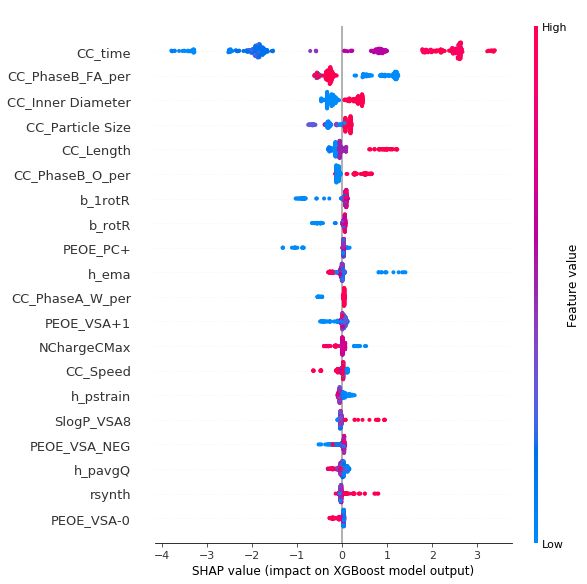

In [13]:
shap.summary_plot(shap_values, X, show=False)
plt.xlabel("SHAP value (impact on XGBoost model output)", fontsize=12)  # 替换为你的自定义文字
plt.show()

In [14]:
from sklearn.ensemble import RandomForestRegressor

# 调用 Random Forest 回归模型
model_rf = RandomForestRegressor(
    n_estimators=2000,        # 树的数量，与XGBoost中的n_estimators对应
    max_depth=5,              # 树的最大深度
    min_samples_split=5,      # 节点最小样本数量，类似于XGBoost中的min_child_weight
    min_samples_leaf=1,       # 叶子节点最小样本数
    max_features=0.66,        # 每棵树考虑的最大特征数，与colsample_bytree对应
    bootstrap=True,           # 是否有放回地抽样
    random_state=123,         # 随机种子，与XGBoost中的seed对应
    n_jobs=-1                 # 并行线程数，使用所有可用CPU
)

In [15]:
model_rf.fit(X_train, y_train)

RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=5,
           max_features=0.66, max_leaf_nodes=None,
           min_impurity_decrease=0.0, min_impurity_split=None,
           min_samples_leaf=1, min_samples_split=5,
           min_weight_fraction_leaf=0.0, n_estimators=2000, n_jobs=-1,
           oob_score=False, random_state=123, verbose=0, warm_start=False)

In [16]:
y_pred = model_rf.predict(X_val)
r2 = pearsonr(y_val, y_pred)[0]**2
print("R2值：", r2)

R2值： 0.9421291369679065


In [17]:
y_pred_test = model_rf.predict(X_test)
r2_test = pearsonr(y_test, y_pred_test)[0]**2
print("R2值（测试集）：", r2_test)

R2值（测试集）： 0.9330372322007233


In [18]:
explainer = shap.Explainer(model_rf)

In [19]:
shap_values = explainer(X)

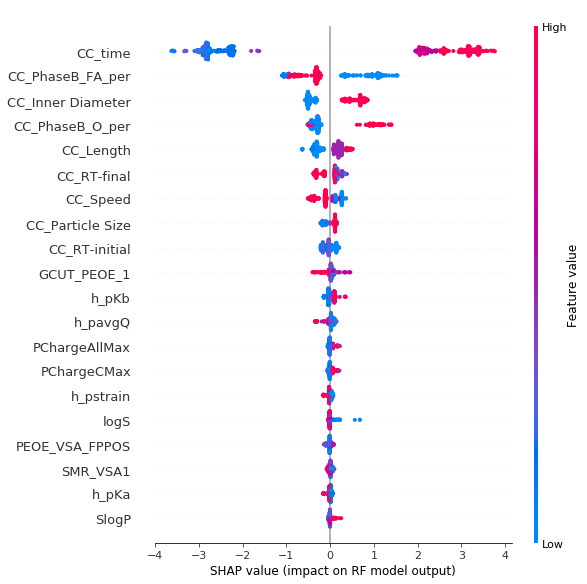

In [20]:
shap.summary_plot(shap_values, X, show=False)
plt.xlabel("SHAP value (impact on RF model output)", fontsize=12)  # 替换为你的自定义文字
plt.show()

In [21]:
import shap
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import os
import time
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.stats.stats import pearsonr
# 1. 定义 FCNN 模型
class FCNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(FCNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# 2. 训练模型的函数
def train_fcnn(X_train, y_train, X_valid, y_valid, input_size, hidden_size, num_epochs=6000, lr=0.001):
    model = FCNN(input_size, hidden_size)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    best_model = None
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_valid)
            val_loss = mean_squared_error(y_valid, val_outputs)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()  # Save best model

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item()}, Validation Loss: {val_loss}')

    model.load_state_dict(best_model)
    return model    
    
# 4. 数据加载和预处理部分
# 假设数据已被加载，并且 CSV 中有特征数据和标签数据
df = pd.read_csv('mPC_CC.csv')
X = df.iloc[:,2:].values  # 特征数据
y= df.iloc[:,1].values  # 标签数据

# 拆分数据集
random_seeds = [2**n for n in range(10)]
for seed in random_seeds:
    # 使用相同的 seed 值来分割训练和验证集
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=seed)

    # 再次使用相同的 seed 值来进一步分割验证集，创建测试集
    X_test, X_temp, y_test, y_temp = train_test_split(X_val, y_val, test_size=0.1, random_state=seed)
#X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# 将数据转换为 PyTorch Tensor
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


# 5. 训练模型
input_size = X_train.shape[1]  # 输入特征的维度
hidden_size = 300
model = train_fcnn(X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, input_size, hidden_size)

model.eval()  # 设置为评估模式
with torch.no_grad():  # 禁用梯度计算
    test_outputs = model(X_test_tensor)  # 获取模型输出
    
test_outputs = test_outputs.numpy()

test_r2 = pearsonr(y_test, test_outputs[:, 0])[0] ** 2
print(f"Test R²: {test_r2}")


Epoch 10/6000, Loss: 12382.736328125, Validation Loss: 8877.6630859375
Epoch 20/6000, Loss: 4200.91455078125, Validation Loss: 1426.2005615234375
Epoch 30/6000, Loss: 828.1874389648438, Validation Loss: 44.05815124511719
Epoch 40/6000, Loss: 45.49380874633789, Validation Loss: 344.3982849121094
Epoch 50/6000, Loss: 250.56671142578125, Validation Loss: 168.5486602783203
Epoch 60/6000, Loss: 32.0285758972168, Validation Loss: 61.95717239379883
Epoch 70/6000, Loss: 55.01140594482422, Validation Loss: 31.54941177368164
Epoch 80/6000, Loss: 35.17397689819336, Validation Loss: 31.362104415893555
Epoch 90/6000, Loss: 26.057437896728516, Validation Loss: 27.930341720581055
Epoch 100/6000, Loss: 21.800254821777344, Validation Loss: 22.7161808013916
Epoch 110/6000, Loss: 19.71526336669922, Validation Loss: 20.63034439086914
Epoch 120/6000, Loss: 17.673553466796875, Validation Loss: 18.056270599365234
Epoch 130/6000, Loss: 16.027023315429688, Validation Loss: 16.68391990661621
Epoch 140/6000, Los

Epoch 1070/6000, Loss: 2.098355293273926, Validation Loss: 2.87965726852417
Epoch 1080/6000, Loss: 2.0844368934631348, Validation Loss: 2.8251564502716064
Epoch 1090/6000, Loss: 2.0067429542541504, Validation Loss: 2.705031156539917
Epoch 1100/6000, Loss: 1.7941269874572754, Validation Loss: 2.6182236671447754
Epoch 1110/6000, Loss: 1.7809137105941772, Validation Loss: 2.6266467571258545
Epoch 1120/6000, Loss: 2.1589572429656982, Validation Loss: 3.2871532440185547
Epoch 1130/6000, Loss: 8.44770622253418, Validation Loss: 6.702664852142334
Epoch 1140/6000, Loss: 4.1075592041015625, Validation Loss: 3.990601062774658
Epoch 1150/6000, Loss: 2.6116645336151123, Validation Loss: 3.3495922088623047
Epoch 1160/6000, Loss: 1.9829527139663696, Validation Loss: 2.752105474472046
Epoch 1170/6000, Loss: 1.7639275789260864, Validation Loss: 2.594069242477417
Epoch 1180/6000, Loss: 1.7704488039016724, Validation Loss: 2.622205972671509
Epoch 1190/6000, Loss: 2.6432178020477295, Validation Loss: 3.8

Epoch 2120/6000, Loss: 1.7277300357818604, Validation Loss: 23.984254837036133
Epoch 2130/6000, Loss: 16.127195358276367, Validation Loss: 15.052268981933594
Epoch 2140/6000, Loss: 5.256257057189941, Validation Loss: 2.181757688522339
Epoch 2150/6000, Loss: 1.5283316373825073, Validation Loss: 2.5733814239501953
Epoch 2160/6000, Loss: 1.8473069667816162, Validation Loss: 2.477479934692383
Epoch 2170/6000, Loss: 1.7658544778823853, Validation Loss: 2.0726749897003174
Epoch 2180/6000, Loss: 1.6032087802886963, Validation Loss: 1.9420932531356812
Epoch 2190/6000, Loss: 1.5321431159973145, Validation Loss: 1.9211331605911255
Epoch 2200/6000, Loss: 1.5072544813156128, Validation Loss: 1.9173861742019653
Epoch 2210/6000, Loss: 1.4963796138763428, Validation Loss: 1.9145338535308838
Epoch 2220/6000, Loss: 1.489417552947998, Validation Loss: 1.9115511178970337
Epoch 2230/6000, Loss: 1.4837126731872559, Validation Loss: 1.9090216159820557
Epoch 2240/6000, Loss: 1.4787068367004395, Validation Lo

Epoch 3160/6000, Loss: 1.7755639553070068, Validation Loss: 6.9161906242370605
Epoch 3170/6000, Loss: 1.7779158353805542, Validation Loss: 6.1535210609436035
Epoch 3180/6000, Loss: 1.9711309671401978, Validation Loss: 3.788226842880249
Epoch 3190/6000, Loss: 1.6158524751663208, Validation Loss: 2.487654447555542
Epoch 3200/6000, Loss: 1.3630053997039795, Validation Loss: 1.9805800914764404
Epoch 3210/6000, Loss: 1.2644357681274414, Validation Loss: 1.8101705312728882
Epoch 3220/6000, Loss: 1.24452543258667, Validation Loss: 1.77165949344635
Epoch 3230/6000, Loss: 1.245868444442749, Validation Loss: 1.7802308797836304
Epoch 3240/6000, Loss: 1.24151611328125, Validation Loss: 1.7911807298660278
Epoch 3250/6000, Loss: 1.2322219610214233, Validation Loss: 1.7859525680541992
Epoch 3260/6000, Loss: 1.2269045114517212, Validation Loss: 1.7735540866851807
Epoch 3270/6000, Loss: 1.2234665155410767, Validation Loss: 1.7673228979110718
Epoch 3280/6000, Loss: 1.2195396423339844, Validation Loss: 1

Epoch 4210/6000, Loss: 1.1771644353866577, Validation Loss: 2.044651508331299
Epoch 4220/6000, Loss: 1.2307511568069458, Validation Loss: 1.9131518602371216
Epoch 4230/6000, Loss: 1.1637122631072998, Validation Loss: 1.8383841514587402
Epoch 4240/6000, Loss: 1.1272844076156616, Validation Loss: 1.8287822008132935
Epoch 4250/6000, Loss: 1.1170639991760254, Validation Loss: 1.8261936902999878
Epoch 4260/6000, Loss: 1.1132867336273193, Validation Loss: 1.8209474086761475
Epoch 4270/6000, Loss: 1.11057710647583, Validation Loss: 1.8153846263885498
Epoch 4280/6000, Loss: 1.1080451011657715, Validation Loss: 1.8091163635253906
Epoch 4290/6000, Loss: 1.1056019067764282, Validation Loss: 1.8036446571350098
Epoch 4300/6000, Loss: 1.1032229661941528, Validation Loss: 1.798959493637085
Epoch 4310/6000, Loss: 1.1008379459381104, Validation Loss: 1.7948768138885498
Epoch 4320/6000, Loss: 1.098488688468933, Validation Loss: 1.79154372215271
Epoch 4330/6000, Loss: 1.0961968898773193, Validation Loss:

Epoch 5250/6000, Loss: 3.565307140350342, Validation Loss: 2.2442028522491455
Epoch 5260/6000, Loss: 2.142605781555176, Validation Loss: 2.1668872833251953
Epoch 5270/6000, Loss: 1.4039955139160156, Validation Loss: 2.012432098388672
Epoch 5280/6000, Loss: 1.063355565071106, Validation Loss: 1.8423080444335938
Epoch 5290/6000, Loss: 0.9965696334838867, Validation Loss: 1.7774412631988525
Epoch 5300/6000, Loss: 1.0087170600891113, Validation Loss: 1.8022043704986572
Epoch 5310/6000, Loss: 0.9947662353515625, Validation Loss: 1.7986787557601929
Epoch 5320/6000, Loss: 0.9883588552474976, Validation Loss: 1.769171953201294
Epoch 5330/6000, Loss: 0.9861230254173279, Validation Loss: 1.7578225135803223
Epoch 5340/6000, Loss: 0.9831377863883972, Validation Loss: 1.7607089281082153
Epoch 5350/6000, Loss: 0.9807644486427307, Validation Loss: 1.7569563388824463
Epoch 5360/6000, Loss: 0.9784676432609558, Validation Loss: 1.7495700120925903
Epoch 5370/6000, Loss: 0.9761828780174255, Validation Los

In [22]:
def predict_fn(X):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        return model(X_tensor).numpy()

In [23]:
explainer = shap.Explainer(predict_fn, X_train)

In [24]:
shap_values = explainer(X)

Permutation explainer: 421it [16:30,  2.22s/it]                                                                        


In [25]:
feature_names = df.columns[2:].tolist()

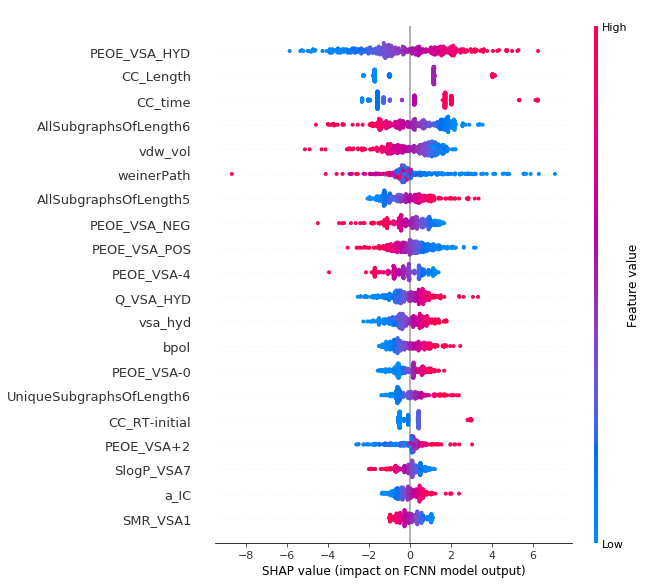

In [26]:
shap.summary_plot(shap_values, X,feature_names=feature_names,show=False)
plt.xlabel("SHAP value (impact on FCNN model output)", fontsize=12)  # 替换为你的自定义文字
plt.show()